# Probing in Code LLMs — Accumulator Variable Role

Mirrors `probing_more_perturbations.ipynb` but probes for **accumulator** variables instead of index/key.

An **accumulator** variable is one that collects a running value across a loop:
- `total += arr[i]`
- `count += 1`
- `product *= x`
- `result.append(x)`

| Strategy | Description |
|----------|-------------|
| `baseline` | Original variable names — control group |
| `random_nouns` | Replace with everyday English nouns (apple, drum, leaf…) |
| `single_chars` | Replace with single lowercase letters cycling a→z |
| `all_same` | Replace every variable with the same name `x` |
| `numeric_vars` | Replace with programmer-style names v1, v2, v3… |
| `misleading` | Accumulator vars get index-sounding names; non-accumulator vars get accumulator-sounding names |

**Central question:** Does Qwen2.5-1.5B detect accumulator role from syntactic pattern (AugAssign inside loop), or from surface variable names like `total`, `count`, `result`?

## Imports & Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from collections import defaultdict
import re
import ast
import random
import string
import os
import json
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

RESULTS_DIR = '../results/accumulator'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results dir: {RESULTS_DIR}')

/Applications/Projects/Algoverse/Coding/algoverse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Results dir: ../results/accumulator


## Model Loading

In [2]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'

print(f'Loading tokenizer and model: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True, trust_remote_code=True)
model.eval()
model.to(DEVICE)

NUM_LAYERS  = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size
print(f'Layers: {NUM_LAYERS}, Hidden size: {HIDDEN_SIZE}')

_probe_ids = tokenizer('x', return_tensors='pt')['input_ids'][0].tolist()
_raw_len   = len(tokenizer.tokenize('x'))
LEADING_SPECIAL = len(_probe_ids) - _raw_len
print(f'Leading special tokens per sequence: {LEADING_SPECIAL}')

Loading tokenizer and model: Qwen/Qwen2.5-1.5B ...


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 9052.15it/s]

Layers: 28, Hidden size: 1536
Leading special tokens per sequence: 0


## Dataset Loading

In [3]:
XLCOST_ROOT  = '/Applications/Projects/Algoverse/Coding/XLCoST_data'
NL2CODE_PROG = os.path.join(XLCOST_ROOT, 'retrieval', 'nl2code_search', 'program_level')


def reconstruct_code(tokens):
    indent_level, lines, current_line = 0, [], []
    for tok in tokens:
        if tok == 'NEW_LINE':
            lines.append('    ' * indent_level + ' '.join(current_line))
            current_line = []
        elif tok == 'INDENT':
            indent_level += 1
        elif tok == 'DEDENT':
            indent_level = max(0, indent_level - 1)
        else:
            current_line.append(tok)
    if current_line:
        lines.append('    ' * indent_level + ' '.join(current_line))
    return '\n'.join(lines).strip()


def load_xlcost_programs(lang, split='train', max_programs=500):
    lang_dir = os.path.join(NL2CODE_PROG, lang)
    fname    = f'{split}.jsonl'
    path     = os.path.join(lang_dir, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(f'Not found: {path}')
    programs = []
    with open(path) as f:
        for line in f:
            if len(programs) >= max_programs:
                break
            rec = json.loads(line)
            toks = rec.get('code_tokens', rec.get('docstring_tokens', []))
            if toks:
                programs.append(reconstruct_code(toks))
    return programs


print('Loading Python programs from XLCoST ...')
RAW_PROGRAMS = load_xlcost_programs('Python', split='train', max_programs=500)
print(f'Loaded {len(RAW_PROGRAMS)} Python programs')
print('\n── Sample program ──────────────────────────────────────────')
print(RAW_PROGRAMS[0][:400])

Loading Python programs from XLCoST ...
Loaded 500 Python programs

── Sample program ──────────────────────────────────────────
def maxPresum ( a , b ) :
    X = max ( a [ 0 ] , 0 )
    for i in range ( 1 , len ( a ) ) :
        a [ i ] += a [ i - 1 ]
        X = max ( X , a [ i ] )
    Y = max ( b [ 0 ] , 0 )
    for i in range ( 1 , len ( b ) ) :
        b [ i ] += b [ i - 1 ]
        Y = max ( Y , b [ i ] )
    return X + Y
A = [ 2 , - 1 , 4 , - 5 ]
B = [ 4 , - 3 , 12 , 4 , - 3 ]
print ( maxPresum ( A , B ) )


## Core Utilities — AST Labeling for Accumulator Role

An **accumulator** is a variable that collects a running value across a loop:
- AugAssign target inside a `for`/`while` body: `total += x`, `count += 1`, `product *= y`
- `.append()`/`.extend()`/`.add()`/`.update()` called on it inside a loop: `result.append(x)`

**Exclusions**:
- Loop variables themselves (`for i in range(n)` — `i` is a loop var, not accumulator)
- Variables used as index/key (if also an accumulator, skip to avoid overlap)
- `_` (throwaway)

In [4]:
import keyword
import builtins

PYTHON_PROTECTED = (
    set(keyword.kwlist)
    | set(dir(builtins))
    | {'self', 'cls', 'None', 'True', 'False'}
)


def get_accumulator_names(code):
    """
    Return variable names used as accumulators in Python code.

    Captures:
      total += arr[i]      →  total
      count += 1           →  count
      product *= x         →  product
      result.append(v)     →  result   (inside a loop)
      res.extend(lst)      →  res      (inside a loop)

    Excludes:
      for i in ...: i      →  loop variables
      _                    →  throwaway
      arr[i]               →  index/key vars (not accumulators)
    """
    accumulators = set()
    try:
        tree = ast.parse(code)
    except SyntaxError:
        return accumulators

    # Collect all loop variables (for-loop targets)
    loop_vars = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.For):
            for n in ast.walk(node.target):
                if isinstance(n, ast.Name):
                    loop_vars.add(n.id)

    # Collect index/key names to exclude overlap
    index_names = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.Subscript):
            slc = node.slice
            if isinstance(slc, ast.Index):
                slc = slc.value
            if isinstance(slc, ast.Name):
                index_names.add(slc.id)

    _APPEND_METHODS = {'append', 'extend', 'add', 'update'}

    # Walk loop bodies for augmented assignments and append-style calls
    for node in ast.walk(tree):
        if not isinstance(node, (ast.For, ast.While)):
            continue
        for stmt in ast.walk(node):
            # AugAssign: total += x, count += 1, product *= y
            if isinstance(stmt, ast.AugAssign):
                if isinstance(stmt.target, ast.Name):
                    name = stmt.target.id
                    if name not in loop_vars and name not in index_names and name != '_':
                        accumulators.add(name)
            # Expr(Call): result.append(x), res.extend(lst)
            elif isinstance(stmt, ast.Expr) and isinstance(stmt.value, ast.Call):
                call = stmt.value
                if (
                    isinstance(call.func, ast.Attribute)
                    and call.func.attr in _APPEND_METHODS
                    and isinstance(call.func.value, ast.Name)
                ):
                    name = call.func.value.id
                    if name not in loop_vars and name not in index_names and name != '_':
                        accumulators.add(name)

    return accumulators


# Sanity checks
_tests = [
    ('total = 0\nfor i in range(n):\n    total += arr[i]',
     {'total'}),
    ('result = []\nfor x in items:\n    result.append(x * 2)',
     {'result'}),
    ('product = 1\nfor v in nums:\n    product *= v',
     {'product'}),
    ('for i in range(n):\n    i += 1',  # i is loop var — should be excluded
     set()),
    ('count = 0\nfor i in range(n):\n    count += 1\n    s += arr[i]',
     {'count', 's'}),
]
print('Accumulator detection tests:')
all_pass = True
for code, expected in _tests:
    got = get_accumulator_names(code)
    ok  = got == expected
    if not ok:
        all_pass = False
    print(f'  {"OK" if ok else "FAIL"}  expected={expected}  got={got}')
print('All pass:', all_pass)

Accumulator detection tests:
  OK  expected={'total'}  got={'total'}
  OK  expected={'result'}  got={'result'}
  OK  expected={'product'}  got={'product'}
  OK  expected=set()  got=set()
  OK  expected={'count', 's'}  got={'count', 's'}
All pass: True


## Token Labeling

In [5]:
def label_tokens(code, target_names, role_name='accumulator'):
    """
    Tokenize `code` and assign binary labels.
    Label = 1 if the token resolves to a target variable name, 0 otherwise.
    Handles BERT (##), GPT2/Qwen (Ġ/▁), and Qwen bracket-merging.
    """
    if not target_names:
        return [], []

    tokens = tokenizer.tokenize(code)
    labels = []
    for tok in tokens:
        is_continuation = tok.startswith('##')
        clean           = tok.lstrip('Ġ▁Ā').lstrip('##')
        clean_stripped  = clean.strip('[]().,;:')
        matched = (
            not is_continuation
            and (clean in target_names or clean_stripped in target_names)
        )
        labels.append(1 if matched else 0)
    return tokens, labels


# Quick check
_demo = 'total = 0\nfor i in range(n):\n    total += arr[i]\nresult.append(total)'
_names = get_accumulator_names(_demo)
print(f'Accumulator names in demo: {_names}')
_toks, _labs = label_tokens(_demo, _names)
print('Labeled tokens (first 30):')
for t, l in list(zip(_toks, _labs))[:30]:
    marker = '  <-- ACCUM' if l == 1 else ''
    print(f'  {repr(t):20s}  {l}{marker}')

Accumulator names in demo: {'total'}
Labeled tokens (first 30):
  'total'               1  <-- ACCUM
  'Ġ='                  0
  'Ġ'                   0
  '0'                   0
  'Ċ'                   0
  'for'                 0
  'Ġi'                  0
  'Ġin'                 0
  'Ġrange'              0
  '(n'                  0
  '):Ċ'                 0
  'ĠĠĠ'                 0
  'Ġtotal'              1  <-- ACCUM
  'Ġ+='                 0
  'Ġarr'                0
  '[i'                  0
  ']Ċ'                  0
  'result'              0
  '.append'             0
  '(total'              1  <-- ACCUM
  ')'                   0


## Identifier Collector (for Perturbations)

In [6]:
def collect_all_identifiers(code):
    """Return all user-defined identifiers from Python code via AST."""
    names = set()
    try:
        tree = ast.parse(code)
        for node in ast.walk(tree):
            if isinstance(node, ast.Name):
                names.add(node.id)
            elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
                names.add(node.name)
            elif isinstance(node, ast.arg):
                names.add(node.arg)
    except SyntaxError:
        for m in re.finditer(r'\b([a-zA-Z_]\w*)\b', code):
            names.add(m.group(1))
    return names - PYTHON_PROTECTED


def apply_rename_map(code, rmap):
    """Apply whole-word substitution; process longest names first to avoid partial matches."""
    for old in sorted(rmap, key=len, reverse=True):
        new  = rmap[old]
        code = re.sub(r'\b' + re.escape(old) + r'\b', new, code)
    return code

## Perturbation Strategies

Each strategy returns `(renamed_code, new_accumulator_names)`.  
For **misleading**: accumulator vars → index-sounding names; non-accumulator vars → accumulator-sounding names.

In [7]:
# ── Name pools ────────────────────────────────────────────────────────────────

RANDOM_NOUNS = sorted(set([
    'apple', 'bag', 'ball', 'basil', 'bear', 'bed', 'belt', 'birch', 'bird', 'bolt',
    'bowl', 'box', 'broom', 'brush', 'cage', 'cart', 'cat', 'cedar', 'clip', 'coat',
    'coin', 'comb', 'cord', 'crow', 'cube', 'cup', 'deer', 'desk', 'dial', 'dish',
    'dog', 'dome', 'drop', 'drum', 'duck', 'dust', 'edge', 'fern', 'fish', 'flame',
    'fork', 'fox', 'frog', 'gate', 'gear', 'gem', 'glove', 'glow', 'grain', 'grid',
    'hat', 'hawk', 'heap', 'hill', 'hole', 'hook', 'hose', 'hull', 'jar', 'kelp',
    'knob', 'knot', 'lamb', 'lamp', 'latch', 'leaf', 'lens', 'lion', 'lobe', 'lock',
    'loop', 'lump', 'maple', 'mark', 'mast', 'mesh', 'mint', 'mist', 'mold', 'mole',
    'moss', 'nail', 'net', 'newt', 'node', 'oak', 'orb', 'palm', 'path', 'peak',
    'pen', 'pile', 'pine', 'pipe', 'plank', 'plate', 'plug', 'pool', 'port', 'pot',
    'puma', 'ramp', 'reed', 'reef', 'ring', 'rod', 'root', 'rope', 'rose', 'rug',
    'sage', 'sand', 'seal', 'seed', 'slab', 'slot', 'stem', 'tree', 'vine', 'wolf',
]))

# Names that LOOK like accumulators (conventional)
ACCUM_LOOKING = [
    'total', 'count', 'result', 'output', 'answer', 'value',
    'amount', 'data', 'temp', 'buf', 'res', 'ret', 'score',
    'maximum', 'minimum', 'current', 'previous', 'running',
    'accumulator', 'product', 'difference', 'sumval', 'tally',
    'aggregate', 'cumsum', 'total_sum', 'running_total',
]

# Names that LOOK like index/loop variables (conventional)
INDEX_LOOKING = [
    'i', 'j', 'k', 'n', 'm', 'idx', 'pos', 'key', 'ptr',
    'cur', 'row', 'col', 'x', 'y', 'p', 'q', 'r', 't', 'u',
]


def _renameable(code):
    return sorted(n for n in collect_all_identifiers(code) if n not in PYTHON_PROTECTED)


# ── 1. Random nouns ───────────────────────────────────────────────────────────
def perturb_random_nouns(code, seed=0):
    rng      = random.Random(seed)
    names    = _renameable(code)
    pool     = rng.sample(RANDOM_NOUNS, min(len(RANDOM_NOUNS), len(names)))
    if len(names) > len(pool):
        pool += rng.choices(RANDOM_NOUNS, k=len(names) - len(pool))
    rmap     = dict(zip(names, pool))
    new_code = apply_rename_map(code, rmap)
    new_acc  = get_accumulator_names(new_code)
    return new_code, new_acc


# ── 2. Single characters ──────────────────────────────────────────────────────
def _single_char_pool(n):
    pool   = list(string.ascii_lowercase)
    suffix = 0
    while len(pool) < n:
        for c in string.ascii_lowercase:
            pool.append(c + str(suffix))
        suffix += 1
    return pool[:n]


def perturb_single_chars(code, seed=0):
    rng      = random.Random(seed)
    names    = _renameable(code)
    pool     = _single_char_pool(len(names))
    rng.shuffle(pool)
    rmap     = dict(zip(names, pool))
    new_code = apply_rename_map(code, rmap)
    new_acc  = get_accumulator_names(new_code)
    return new_code, new_acc


# ── 3. All same name ('x') ────────────────────────────────────────────────────
def perturb_all_same(code, seed=0):
    names    = _renameable(code)
    rmap     = {n: 'x' for n in names}
    new_code = apply_rename_map(code, rmap)
    new_acc  = get_accumulator_names(new_code)
    return new_code, new_acc


# ── 4. Numeric names (v1, v2, v3 …) ──────────────────────────────────────────
def perturb_numeric_vars(code, seed=0):
    rng      = random.Random(seed)
    names    = _renameable(code)
    indices  = list(range(1, len(names) + 1))
    rng.shuffle(indices)
    rmap     = {n: f'v{idx}' for n, idx in zip(names, indices)}
    new_code = apply_rename_map(code, rmap)
    new_acc  = get_accumulator_names(new_code)
    return new_code, new_acc


# ── 5. Misleading names ───────────────────────────────────────────────────────
# Accumulator vars → index-sounding names (i, j, k, idx …)
# Non-accumulator vars → accumulator-sounding names (total, count, result …)
def perturb_misleading(code, seed=0):
    rng       = random.Random(seed)
    all_names = _renameable(code)
    acc_names = get_accumulator_names(code)

    acc_vars    = sorted(n for n in all_names if n in acc_names)
    normal_vars = sorted(n for n in all_names if n not in acc_names)

    # Extend pools if needed
    index_pool = INDEX_LOOKING * (len(acc_vars) // max(len(INDEX_LOOKING), 1) + 2)
    rng.shuffle(index_pool)
    accum_pool = ACCUM_LOOKING * (len(normal_vars) // max(len(ACCUM_LOOKING), 1) + 2)
    rng.shuffle(accum_pool)

    rmap = {}
    for var, new_name in zip(acc_vars, index_pool):
        rmap[var] = new_name       # accumulator var → looks like index
    for var, new_name in zip(normal_vars, accum_pool):
        rmap[var] = new_name       # normal var → looks like accumulator

    new_code = apply_rename_map(code, rmap)
    new_acc  = get_accumulator_names(new_code)
    return new_code, new_acc


# ── Strategy registry ─────────────────────────────────────────────────────────
PERTURBATIONS = {
    'baseline':     None,
    'random_nouns': perturb_random_nouns,
    'single_chars': perturb_single_chars,
    'all_same':     perturb_all_same,
    'numeric_vars': perturb_numeric_vars,
    'misleading':   perturb_misleading,
}

print('Perturbation strategies:', list(PERTURBATIONS.keys()))

# Sanity check
_demo = 'total = 0\nfor i in range(n):\n    total += arr[i]\nresult = []\nfor v in nums:\n    result.append(v)'
print(f'\nOriginal accumulators: {get_accumulator_names(_demo)}')
for name, fn in PERTURBATIONS.items():
    if fn is None:
        print(f'{name:15s}  (no change)')
        continue
    new_code, new_acc = fn(_demo, seed=42)
    print(f'{name:15s}  {new_acc}  | snippet: {new_code[:60]!r}')

Perturbation strategies: ['baseline', 'random_nouns', 'single_chars', 'all_same', 'numeric_vars', 'misleading']

Original accumulators: {'total', 'result'}
baseline         (no change)
random_nouns     {'dust', 'dome'}  | snippet: 'dome = 0\nfor cage in range(basil):\n    dome += nail[cage]\ndu'
single_chars     {'a', 'g'}  | snippet: 'a = 0\nfor d in range(e):\n    a += b[d]\ng = []\nfor f in c:\n  '
all_same         set()  | snippet: 'x = 0\nfor x in range(x):\n    x += x[x]\nx = []\nfor x in x:\n  '
numeric_vars     {'v7', 'v1'}  | snippet: 'v1 = 0\nfor v4 in range(v5):\n    v1 += v2[v4]\nv7 = []\nfor v6 '
misleading       {'p', 'col'}  | snippet: 'p = 0\nfor res in range(current):\n    p += buf[res]\ncol = []\n'


## Dataset Builder, Hidden State Extractor, Probe Trainer

In [8]:
from tqdm.auto import tqdm

MAX_SEQ_LEN = 512


def build_dataset(programs, perturb_fn=None, role_name='accumulator'):
    dataset, skipped = [], 0
    for idx, code in enumerate(programs):
        if perturb_fn is None:
            new_code = code
            new_acc  = get_accumulator_names(code)
        else:
            new_code, new_acc = perturb_fn(code, seed=idx)

        if not new_acc:
            skipped += 1
            continue

        tokens, labels = label_tokens(new_code, new_acc)
        if not tokens or sum(labels) == 0:
            skipped += 1
            continue

        dataset.append({
            'code': new_code, 'tokens': tokens, 'labels': labels,
            'target_names': new_acc, 'role': role_name,
        })

    total_pos = sum(sum(d['labels']) for d in dataset)
    total_tok = sum(len(d['tokens']) for d in dataset)
    pct = 100 * total_pos / total_tok if total_tok else 0
    print(f'[{role_name:22s}]  {len(dataset):3d} programs  |  '
          f'{total_pos:,} pos / {total_tok:,} total ({pct:.1f}%)  |  {skipped} skipped')
    return dataset


def extract_hidden_states(dataset):
    all_hidden     = defaultdict(list)
    all_labels     = []
    all_token_strs = []

    with torch.no_grad():
        for sample in tqdm(dataset, desc='Extracting hidden states'):
            code   = sample['code']
            labels = sample['labels']

            encoding = tokenizer(
                code,
                return_tensors='pt',
                truncation=True,
                max_length=MAX_SEQ_LEN,
                padding=False,
            ).to(DEVICE)

            encoded_len = encoding['input_ids'].shape[1] - LEADING_SPECIAL
            labels_trunc = labels[:encoded_len]

            outputs = model(**encoding)
            for layer_idx, hs in enumerate(outputs.hidden_states):
                # hidden_states[layer_idx] shape: (1, seq_len, hidden_size)
                # .float() casts BFloat16 → float32 before numpy conversion
                layer_vecs = hs[0, LEADING_SPECIAL:LEADING_SPECIAL + len(labels_trunc)].cpu().float().numpy()
                all_hidden[layer_idx].extend(layer_vecs)

            all_labels.extend(labels_trunc)
            all_token_strs.extend(sample['tokens'][:encoded_len])

    all_hidden = {k: np.array(v) for k, v in all_hidden.items()}
    all_labels = np.array(all_labels)
    return all_hidden, all_labels, all_token_strs


def train_probes(hidden_states_by_layer, labels, test_size=0.2, random_state=42):
    n = len(labels)
    train_idx, test_idx = train_test_split(
        np.arange(n), test_size=test_size, random_state=random_state, stratify=labels
    )

    results = {}
    for layer_idx in tqdm(sorted(hidden_states_by_layer.keys()), desc='Training probes'):
        X = hidden_states_by_layer[layer_idx]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]

        clf = LogisticRegression(
            max_iter=1000, class_weight='balanced',
            random_state=random_state, C=1.0
        )
        clf.fit(X_train, y_train)

        y_pred_train = clf.predict(X_train)
        y_pred_test  = clf.predict(X_test)

        results[layer_idx] = {
            'probe':     clf,
            'train_acc': accuracy_score(y_train, y_pred_train),
            'test_acc':  accuracy_score(y_test,  y_pred_test),
            'train_f1':  f1_score(y_train, y_pred_train, average='macro', zero_division=0),
            'test_f1':   f1_score(y_test,  y_pred_test,  average='macro', zero_division=0),
            'test_idx':  test_idx,
        }

    return results

## Class Distribution Check (Baseline)

Before running all perturbations, check how common accumulators are in the dataset.

In [9]:
print('Building baseline dataset (no perturbation) ...')
_baseline_ds = build_dataset(RAW_PROGRAMS, perturb_fn=None, role_name='accumulator_baseline_check')

if _baseline_ds:
    _all_labs = np.array([l for d in _baseline_ds for l in d['labels']])
    _counts   = np.bincount(_all_labs)
    _total    = len(_all_labs)
    _n_neg, _n_pos = _counts[0], _counts[1]
    print(f'\nClass distribution (all tokens, baseline):')
    print(f'  Non-accum (0): {_n_neg:>7,}  ({100*_n_neg/_total:.1f}%)')
    print(f'  Accumulator(1): {_n_pos:>7,}  ({100*_n_pos/_total:.1f}%)')
    print(f'  Imbalance ratio: {_n_neg/_n_pos:.1f}:1')
    print(f'  Naive all-zero baseline accuracy: {100*_n_neg/_total:.1f}%')
else:
    print('WARNING: No programs found with accumulator variables!')

Building baseline dataset (no perturbation) ...
[accumulator_baseline_check]  181 programs  |  1,279 pos / 37,527 total (3.4%)  |  319 skipped

Class distribution (all tokens, baseline):
  Non-accum (0):  36,248  (96.6%)
  Accumulator(1):   1,279  (3.4%)
  Imbalance ratio: 28.3:1
  Naive all-zero baseline accuracy: 96.6%


## Run All Perturbations

In [10]:
all_results = {}   # strategy → probe results dict
all_hidden  = {}   # strategy → hidden state dict
all_labels  = {}   # strategy → labels array

for strategy_name, perturb_fn in PERTURBATIONS.items():
    print(f'\n{"="*60}')
    print(f'  Strategy: {strategy_name}')
    print(f'{"="*60}')

    dataset = build_dataset(
        RAW_PROGRAMS,
        perturb_fn=perturb_fn,
        role_name=f'accumulator_{strategy_name}'
    )
    if not dataset:
        print(f'  No valid data — skipping.')
        continue

    print(f'  Extracting hidden states ...')
    hidden, labels, _ = extract_hidden_states(dataset)

    print(f'  Training probes ...')
    results = train_probes(hidden, labels)

    all_results[strategy_name] = results
    all_hidden[strategy_name]  = hidden
    all_labels[strategy_name]  = labels

    best_l   = max(results, key=lambda l: results[l]['test_f1'])
    best_acc = results[best_l]['test_acc']
    best_f1  = results[best_l]['test_f1']
    print(f'  Best layer: {best_l}  acc={best_acc:.3f}  f1={best_f1:.3f}')

print('\nAll strategies done:', list(all_results.keys()))


  Strategy: baseline
[accumulator_baseline  ]  181 programs  |  1,279 pos / 37,527 total (3.4%)  |  319 skipped
  Extracting hidden states ...


Extracting hidden states: 100%|██████████| 181/181 [12:14<00:00,  4.06s/it]


  Training probes ...


Training probes: 100%|██████████| 29/29 [06:23<00:00, 13.23s/it]


  Best layer: 9  acc=0.984  f1=0.893

  Strategy: random_nouns
[accumulator_random_nouns]  204 programs  |  1,498 pos / 40,594 total (3.7%)  |  296 skipped
  Extracting hidden states ...


...

  Best layer: 3  acc=0.999  f1=0.986

  Strategy: misleading
[accumulator_misleading]  204 programs  |  1,674 pos / 41,288 total (4.1%)  |  296 skipped
  Extracting hidden states ...


Extracting hidden states: 100%|██████████| 204/204 [13:59<00:00,  4.12s/it]


  Training probes ...


Training probes: 100%|██████████| 29/29 [03:58<00:00,  8.21s/it]

  Best layer: 6  acc=0.996  f1=0.973

All strategies done: ['baseline', 'random_nouns', 'single_chars', 'all_same', 'numeric_vars', 'misleading']


## Per-Layer Tables

In [11]:
layers = sorted(next(iter(all_results.values())).keys())

for strategy_name, results in all_results.items():
    print(f'\n── {strategy_name} ─────────────────────────────────────────')
    print(f'{"Layer":>7}  {"Train Acc":>10}  {"Test Acc":>10}  {"Train F1":>10}  {"Test F1":>10}')
    print('-' * 56)
    for l in layers:
        r = results[l]
        print(f'{l:>7}  {r["train_acc"]:>10.3f}  {r["test_acc"]:>10.3f}  '
              f'{r["train_f1"]:>10.3f}  {r["test_f1"]:>10.3f}')


── baseline ─────────────────────────────────────────
  Layer   Train Acc    Test Acc    Train F1     Test F1
--------------------------------------------------------
      0       0.894       0.896       0.666       0.668
      1       0.970       0.965       0.838       0.812
      2       0.978       0.969       0.871       0.824
      3       0.988       0.980       0.922       0.873
      4       0.990       0.982       0.935       0.880
      5       0.993       0.981       0.949       0.876
      6       0.993       0.982       0.953       0.879
      7       0.994       0.982       0.958       0.877
      8       0.994       0.983       0.959       0.882
      9       0.996       0.984       0.973       0.893
     10       0.997       0.983       0.975       0.882
     11       0.997       0.983       0.977       0.884
     12       0.997       0.981       0.979       0.871
     13       0.997       0.983       0.980       0.884
     14       0.998       0.980       0.982     

## Visualization

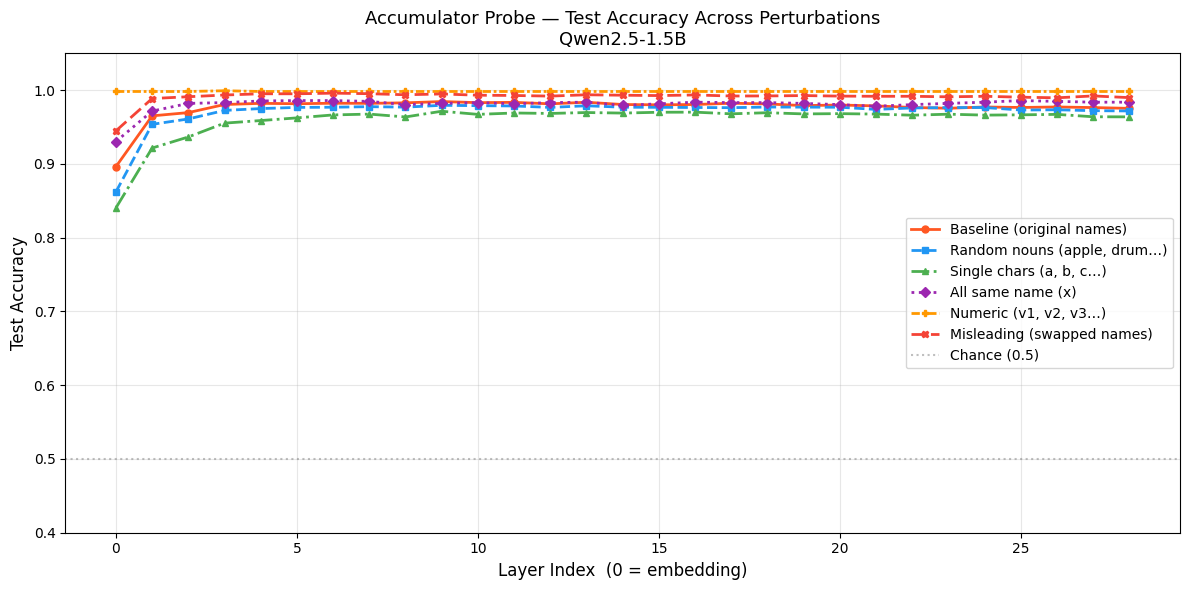

Saved: ../results/accumulator/probe_accuracy_accumulator.png


In [12]:
COLORS = {
    'baseline':     '#FF5722',
    'random_nouns': '#2196F3',
    'single_chars': '#4CAF50',
    'all_same':     '#9C27B0',
    'numeric_vars': '#FF9800',
    'misleading':   '#F44336',
}
MARKERS = {
    'baseline':     'o',
    'random_nouns': 's',
    'single_chars': '^',
    'all_same':     'D',
    'numeric_vars': 'P',
    'misleading':   'X',
}
LINESTYLES = {
    'baseline':     '-',
    'random_nouns': '--',
    'single_chars': '-.',
    'all_same':     ':',
    'numeric_vars': (0, (3, 1, 1, 1)),
    'misleading':   (0, (5, 2)),
}
LABELS = {
    'baseline':     'Baseline (original names)',
    'random_nouns': 'Random nouns (apple, drum…)',
    'single_chars': 'Single chars (a, b, c…)',
    'all_same':     'All same name (x)',
    'numeric_vars': 'Numeric (v1, v2, v3…)',
    'misleading':   'Misleading (swapped names)',
}


# ── Plot 1: Test Accuracy ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for strategy, results in all_results.items():
    accs = [results[l]['test_acc'] for l in layers]
    ax.plot(layers, accs,
            marker=MARKERS.get(strategy, 'o'),
            color=COLORS.get(strategy, 'gray'),
            linestyle=LINESTYLES.get(strategy, '-'),
            linewidth=2, markersize=5,
            label=LABELS.get(strategy, strategy))

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance (0.5)')
ax.set_xlabel('Layer Index  (0 = embedding)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title(f'Accumulator Probe — Test Accuracy Across Perturbations\n{MODEL_NAME.split("/")[-1]}', fontsize=13)
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/probe_accuracy_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR}/probe_accuracy_accumulator.png')

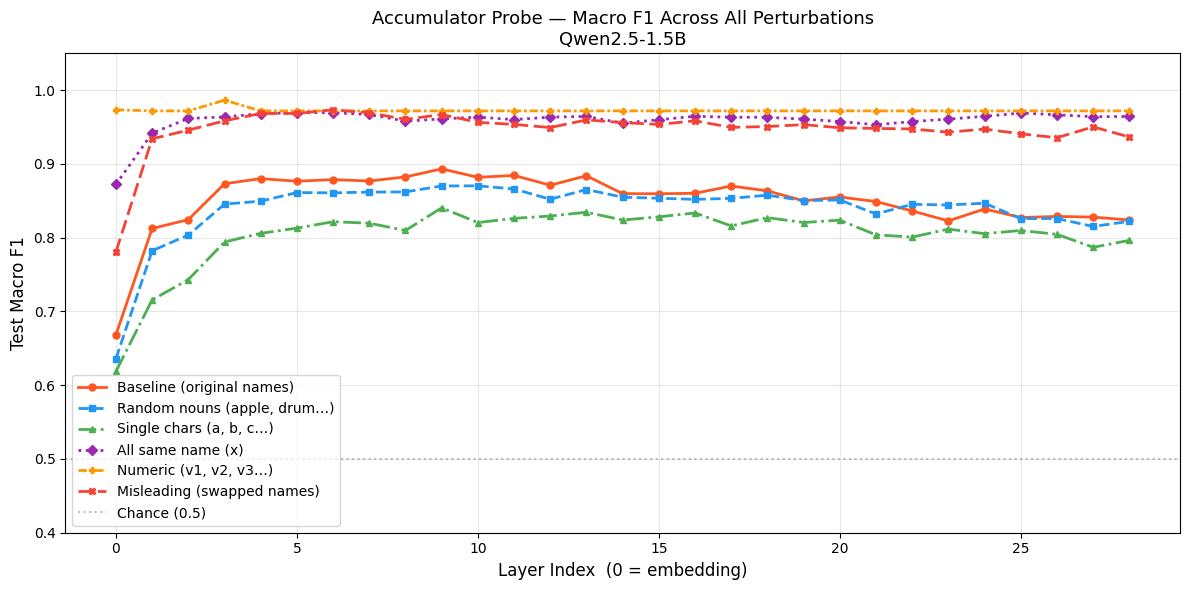

In [13]:
# ── Plot 2: Macro F1 ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for strategy, results in all_results.items():
    f1s = [results[l]['test_f1'] for l in layers]
    ax.plot(layers, f1s,
            marker=MARKERS.get(strategy, 'o'),
            color=COLORS.get(strategy, 'gray'),
            linestyle=LINESTYLES.get(strategy, '-'),
            linewidth=2, markersize=5,
            label=LABELS.get(strategy, strategy))

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance (0.5)')
ax.set_xlabel('Layer Index  (0 = embedding)', fontsize=12)
ax.set_ylabel('Test Macro F1', fontsize=12)
ax.set_title(f'Accumulator Probe — Macro F1 Across All Perturbations\n{MODEL_NAME.split("/")[-1]}', fontsize=13)
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/probe_f1_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

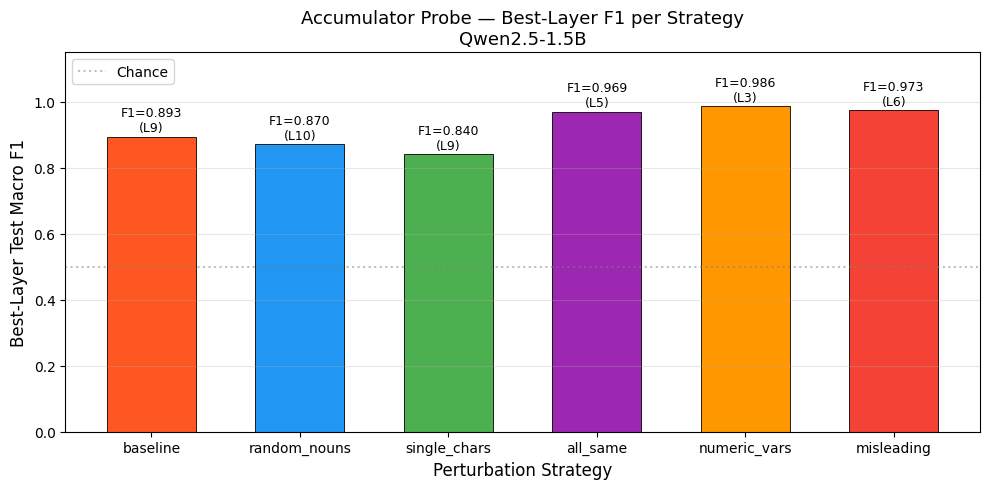

In [14]:
# ── Plot 3: Best-layer F1 bar chart ──────────────────────────────────────────
strategy_names = list(all_results.keys())
best_f1s       = [max(all_results[s][l]['test_f1'] for l in layers) for s in strategy_names]
best_layers    = [max(all_results[s], key=lambda l: all_results[s][l]['test_f1']) for s in strategy_names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(strategy_names, best_f1s,
              color=[COLORS.get(s, 'gray') for s in strategy_names],
              edgecolor='black', linewidth=0.6, width=0.6)

for bar, f1, layer in zip(bars, best_f1s, best_layers):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'F1={f1:.3f}\n(L{layer})',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Perturbation Strategy', fontsize=12)
ax.set_ylabel('Best-Layer Test Macro F1', fontsize=12)
ax.set_title(f'Accumulator Probe — Best-Layer F1 per Strategy\n{MODEL_NAME.split("/")[-1]}', fontsize=13)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/best_layer_f1_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

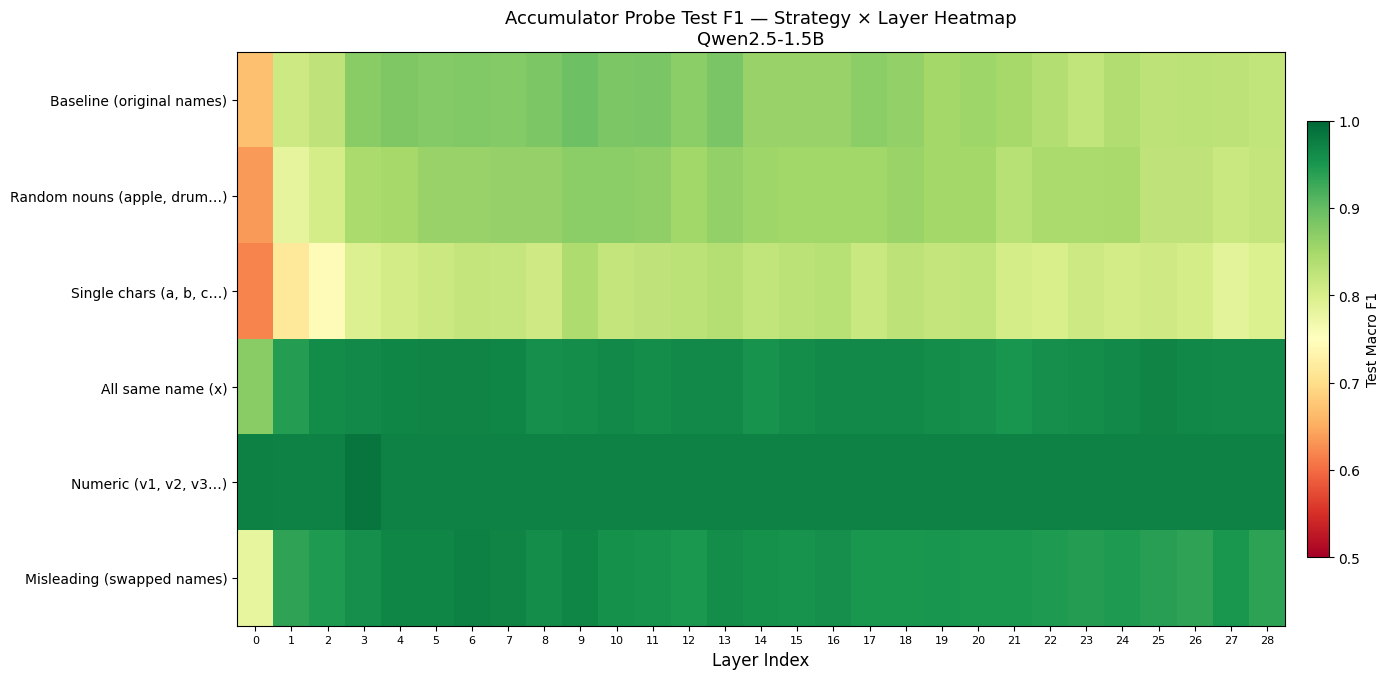

In [15]:
# ── Plot 4: Heatmap — strategy × layer F1 ────────────────────────────────────
heatmap_data = np.array([
    [all_results[s][l]['test_f1'] for l in layers]
    for s in strategy_names
])

fig, ax = plt.subplots(figsize=(14, len(strategy_names) * 0.9 + 1.5))
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.0)

ax.set_xticks(range(len(layers)))
ax.set_xticklabels(layers, fontsize=8)
ax.set_yticks(range(len(strategy_names)))
ax.set_yticklabels([LABELS.get(s, s) for s in strategy_names], fontsize=10)
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_title(f'Accumulator Probe Test F1 — Strategy × Layer Heatmap\n{MODEL_NAME.split("/")[-1]}', fontsize=13)
plt.colorbar(im, ax=ax, label='Test Macro F1', fraction=0.02, pad=0.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/heatmap_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

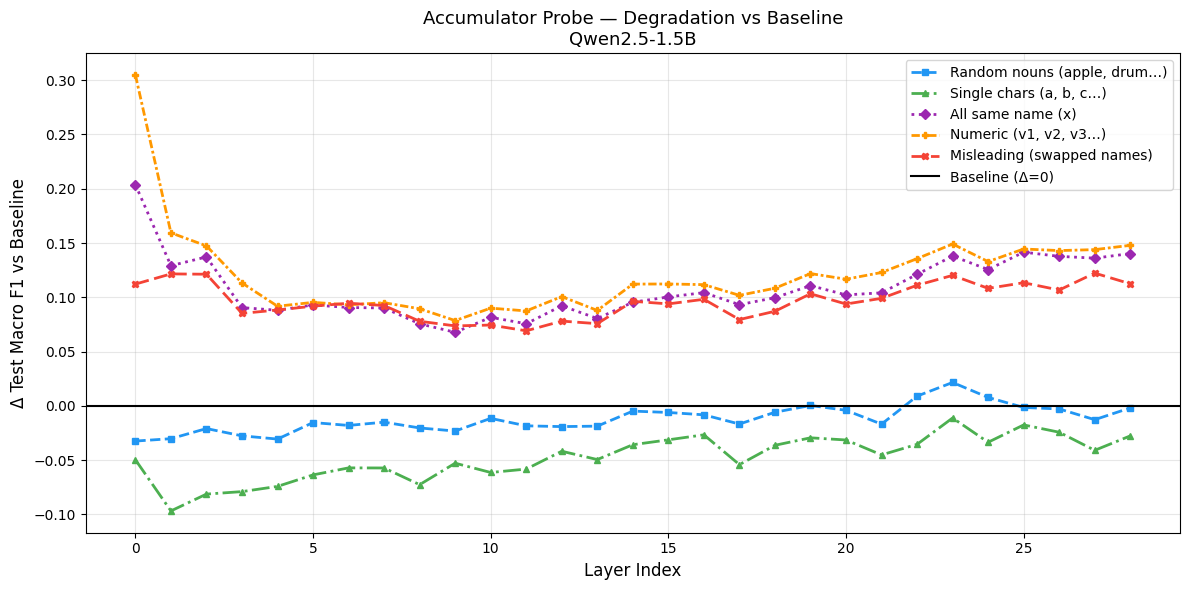

In [16]:
# ── Plot 5: Δ F1 vs baseline ──────────────────────────────────────────────────
if 'baseline' in all_results:
    baseline_f1 = np.array([all_results['baseline'][l]['test_f1'] for l in layers])

    fig, ax = plt.subplots(figsize=(12, 6))
    for strategy, results in all_results.items():
        if strategy == 'baseline':
            continue
        perturbed_f1 = np.array([results[l]['test_f1'] for l in layers])
        delta = perturbed_f1 - baseline_f1
        ax.plot(layers, delta,
                marker=MARKERS.get(strategy, 'o'),
                color=COLORS.get(strategy, 'gray'),
                linestyle=LINESTYLES.get(strategy, '-'),
                linewidth=2, markersize=5,
                label=LABELS.get(strategy, strategy))

    ax.axhline(0, color='black', linewidth=1.5, label='Baseline (Δ=0)')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Δ Test Macro F1 vs Baseline', fontsize=12)
    ax.set_title(f'Accumulator Probe — Degradation vs Baseline\n{MODEL_NAME.split("/")[-1]}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/delta_f1_accumulator.png', dpi=150, bbox_inches='tight')
    plt.show()

## Best-Layer Classification Reports

In [17]:
for strategy_name, results in all_results.items():
    best_layer = max(results, key=lambda l: results[l]['test_f1'])
    test_idx   = results[best_layer]['test_idx']
    clf        = results[best_layer]['probe']

    lbs = all_labels[strategy_name]
    h   = all_hidden[strategy_name]

    X_test = h[best_layer][test_idx]
    y_test = lbs[test_idx]
    y_pred = clf.predict(X_test)

    print(f'\n── {strategy_name}  (best layer: {best_layer}) ────────────────────────────────')
    print(classification_report(y_test, y_pred, target_names=['non-accum', 'accumulator']))

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f'  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
    print(f'  TPR={tp/(tp+fn):.3f}  FPR={fp/(fp+tn):.3f}  Precision={tp/(tp+fp):.3f}')


── baseline  (best layer: 9) ────────────────────────────────
              precision    recall  f1-score   support

   non-accum       1.00      0.99      0.99      7228
 accumulator       0.72      0.88      0.79       256

    accuracy                           0.98      7484
   macro avg       0.86      0.94      0.89      7484
weighted avg       0.99      0.98      0.99      7484

  TN=7,141  FP=87  FN=30  TP=226
  TPR=0.883  FPR=0.012  Precision=0.722

── random_nouns  (best layer: 10) ────────────────────────────────
              precision    recall  f1-score   support

   non-accum       0.99      0.98      0.99      7809
 accumulator       0.66      0.87      0.75       300

    accuracy                           0.98      8109
   macro avg       0.83      0.92      0.87      8109
weighted avg       0.98      0.98      0.98      8109

  TN=7,677  FP=132  FN=40  TP=260
  TPR=0.867  FPR=0.017  Precision=0.663

── single_chars  (best layer: 9) ────────────────────────────────
 

## Probe Weight Cosine Similarity vs Baseline

High similarity = the model uses the same latent direction regardless of surface names.

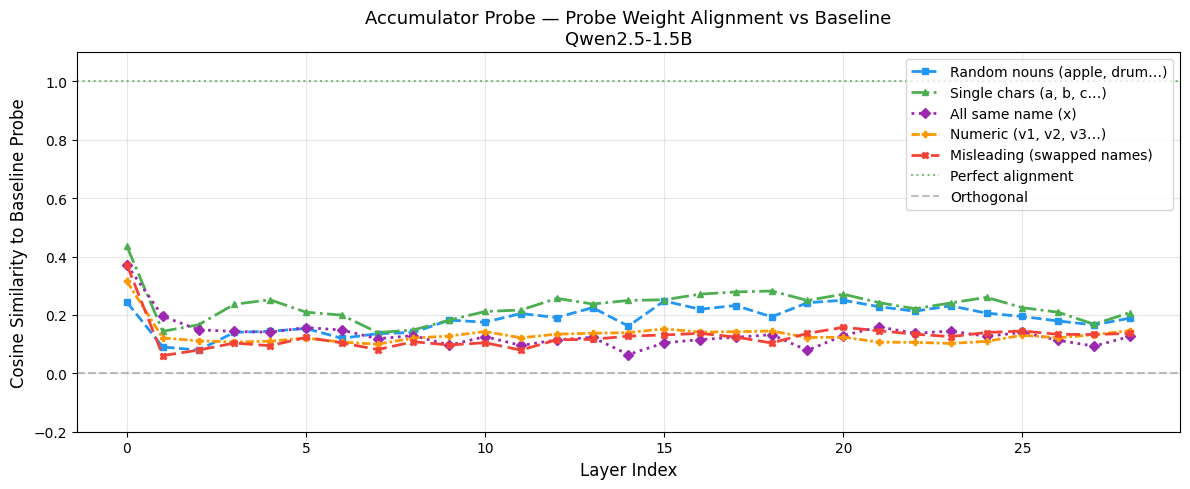


Mean cosine similarity to baseline (across layers):
  random_nouns        0.185
  single_chars        0.230
  all_same            0.134
  numeric_vars        0.131
  misleading          0.126


In [18]:
from numpy.linalg import norm

if 'baseline' not in all_results:
    print('Baseline not available — skipping cosine plot.')
else:
    fig, ax = plt.subplots(figsize=(12, 5))

    cosine_table = {}
    for strategy_name, results in all_results.items():
        if strategy_name == 'baseline':
            continue
        sims = []
        for l in layers:
            w_base    = all_results['baseline'][l]['probe'].coef_[0]
            w_perturb = results[l]['probe'].coef_[0]
            sims.append(np.dot(w_base, w_perturb) / (norm(w_base) * norm(w_perturb)))
        cosine_table[strategy_name] = sims

        ax.plot(layers, sims,
                marker=MARKERS.get(strategy_name, 'o'),
                color=COLORS.get(strategy_name, 'gray'),
                linestyle=LINESTYLES.get(strategy_name, '-'),
                linewidth=2, markersize=5,
                label=LABELS.get(strategy_name, strategy_name))

    ax.axhline(1.0, color='green', linestyle=':', alpha=0.5, label='Perfect alignment')
    ax.axhline(0.0, color='gray',  linestyle='--', alpha=0.5, label='Orthogonal')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Cosine Similarity to Baseline Probe', fontsize=12)
    ax.set_title(f'Accumulator Probe — Probe Weight Alignment vs Baseline\n{MODEL_NAME.split("/")[-1]}', fontsize=13)
    ax.set_ylim(-0.2, 1.1)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cosine_similarity_accumulator.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nMean cosine similarity to baseline (across layers):')
    for s, sims in cosine_table.items():
        print(f'  {s:18s}  {np.mean(sims):.3f}')

## Summary Table

In [19]:
print(f'\n{"Strategy":18s}  {"Best Layer":>10}  {"Best Acc":>9}  {"Best F1":>8}  '
      f'{"Δ Acc vs base":>14}  {"Δ F1 vs base":>13}')
print('-' * 82)

base_best_acc = max(all_results['baseline'][l]['test_acc'] for l in layers) if 'baseline' in all_results else None
base_best_f1  = max(all_results['baseline'][l]['test_f1']  for l in layers) if 'baseline' in all_results else None

for s, results in all_results.items():
    best_l   = max(results, key=lambda l: results[l]['test_f1'])
    best_acc = results[best_l]['test_acc']
    best_f1  = results[best_l]['test_f1']
    d_acc = f'{best_acc - base_best_acc:+.3f}' if base_best_acc and s != 'baseline' else '—'
    d_f1  = f'{best_f1  - base_best_f1 :+.3f}' if base_best_f1  and s != 'baseline' else '—'
    print(f'{s:18s}  {best_l:>10d}  {best_acc:>9.3f}  {best_f1:>8.3f}  {d_acc:>14}  {d_f1:>13}')


Strategy            Best Layer   Best Acc   Best F1   Δ Acc vs base   Δ F1 vs base
----------------------------------------------------------------------------------
baseline                     9      0.984     0.893               —              —
random_nouns                10      0.979     0.870          -0.006         -0.023
single_chars                 9      0.971     0.840          -0.013         -0.053
all_same                     5      0.986     0.969          +0.001         +0.076
numeric_vars                 3      0.999     0.986          +0.015         +0.093
misleading                   6      0.996     0.973          +0.011         +0.080


## Cross-Language Generalization

Train probe on Python accumulators, evaluate on Java/C++/C/C#/JavaScript.

For non-Python languages we detect accumulators via regex:
- AugAssign: `total += x`, `count++`, `sum -= y`
- Append-style: `result.add(x)`, `list.push(x)`

In [20]:
_C_KEYWORDS = {
    'int', 'long', 'char', 'short', 'float', 'double', 'unsigned', 'void',
    'size_t', 'bool', 'true', 'false', 'null', 'NULL',
}
_JAVA_KEYWORDS = {
    'int', 'long', 'char', 'byte', 'short', 'boolean', 'float', 'double',
    'String', 'Integer', 'Long', 'Object', 'null', 'true', 'false',
}
_CSHARP_KEYWORDS = {
    'int', 'long', 'char', 'byte', 'short', 'bool', 'float', 'double',
    'string', 'object', 'null', 'true', 'false', 'var',
}
_JS_KEYWORDS = {
    'undefined', 'null', 'true', 'false', 'NaN', 'Infinity',
    'length', 'prototype', 'constructor',
}

# AugAssign patterns: var += x, var -= x, var *= x, var++ (Java/C++)
_AUGASSIGN_RE   = re.compile(r'\b([a-zA-Z_]\w*)\s*(?:\+=|-=|\*=|/=|\|=|&=|\^=)')
_INCREMENT_RE   = re.compile(r'\b([a-zA-Z_]\w*)\s*(?:\+\+|--)')
# append-style: result.add(x), list.push(x), buf.append(x)
_APPEND_RE      = re.compile(r'\b([a-zA-Z_]\w*)\.(?:add|push|append|extend|offer)\s*\(')


def _get_accum_regex(code, exclude=None):
    """Generic regex-based accumulator extractor for non-Python languages."""
    candidates = set()
    for m in _AUGASSIGN_RE.finditer(code):
        candidates.add(m.group(1))
    for m in _INCREMENT_RE.finditer(code):
        candidates.add(m.group(1))
    for m in _APPEND_RE.finditer(code):
        candidates.add(m.group(1))
    if exclude:
        candidates -= exclude
    return candidates


def get_java_accumulator_names(code):
    return _get_accum_regex(code, exclude=_JAVA_KEYWORDS)

def get_cpp_accumulator_names(code):
    return _get_accum_regex(code, exclude=_C_KEYWORDS)

def get_c_accumulator_names(code):
    return _get_accum_regex(code, exclude=_C_KEYWORDS)

def get_csharp_accumulator_names(code):
    return _get_accum_regex(code, exclude=_CSHARP_KEYWORDS)

def get_js_accumulator_names(code):
    return _get_accum_regex(code, exclude=_JS_KEYWORDS)

def get_php_accumulator_names(code):
    # PHP variables start with $; strip it for matching
    code_stripped = re.sub(r'\$([a-zA-Z_]\w*)', r'\1', code)
    return _get_accum_regex(code_stripped)


LANG_EXTRACTORS = {
    'Python':     get_accumulator_names,
    'Java':       get_java_accumulator_names,
    'C++':        get_cpp_accumulator_names,
    'C':          get_c_accumulator_names,
    'C#':         get_csharp_accumulator_names,
    'Javascript': get_js_accumulator_names,
    'PHP':        get_php_accumulator_names,
}

# Verify on a couple of Java examples
_java_demo = 'int total = 0;\nfor (int i = 0; i < n; i++) {\n    total += arr[i];\n}'
print('Java accumulator test:', get_java_accumulator_names(_java_demo))
_cpp_demo = 'long product = 1;\nfor (int i = 0; i < n; i++) {\n    product *= nums[i];\n}'
print('C++ accumulator test:', get_cpp_accumulator_names(_cpp_demo))

Java accumulator test: {'i', 'total'}
C++ accumulator test: {'product', 'i'}


: 

In [21]:
# Use baseline Python probe for cross-language evaluation
py_results = all_results.get('baseline')
py_hidden  = all_hidden.get('baseline')
py_labels  = all_labels.get('baseline')

if py_results is None:
    print('Baseline Python results missing — skipping cross-language eval.')
else:
    lang_hidden_cl  = {'Python': (py_hidden,  py_labels)}
    lang_results_cl = {'Python': py_results}
    lang_cross      = {}
    lang_cosine_cl  = {}

    OTHER_LANGS = ['Java', 'C++', 'C', 'C#', 'Javascript', 'PHP']

    for lang in OTHER_LANGS:
        print(f'\n{"="*55}')
        print(f'  Language: {lang}')
        print(f'{"="*55}')

        try:
            programs = load_xlcost_programs(lang, split='train', max_programs=300)
        except FileNotFoundError as e:
            print(f'  Skipping — {e}')
            continue
        print(f'  Loaded {len(programs)} programs')

        extractor = LANG_EXTRACTORS[lang]
        data = []
        skipped = 0
        for code in programs:
            names = extractor(code)
            if not names:
                skipped += 1
                continue
            toks, labs = label_tokens(code, names)
            if toks and sum(labs) > 0:
                data.append({'code': code, 'tokens': toks, 'labels': labs, 'target_names': names})
            else:
                skipped += 1
        print(f'  {len(data)} programs with accumulators ({skipped} skipped)')
        if not data:
            continue

        lang_h, lang_l, _ = extract_hidden_states(data)
        print(f'  Tokens: {len(lang_l):,}  positive: {sum(lang_l):,}')

        # Cross-language: apply Python-trained probe
        cross_accs = {}
        for layer_idx in sorted(py_results.keys()):
            if layer_idx not in lang_h:
                continue
            probe  = py_results[layer_idx]['probe']
            y_pred = probe.predict(lang_h[layer_idx])
            cross_accs[layer_idx] = accuracy_score(lang_l, y_pred)
        lang_cross[lang] = cross_accs

        # In-domain language probe + cosine similarity
        if len(lang_l) >= 20 and sum(lang_l) >= 5:
            lang_probes = train_probes(lang_h, lang_l)
            lang_results_cl[lang] = lang_probes
            lang_hidden_cl[lang]  = (lang_h, lang_l)

            sims = []
            for l in sorted(py_results.keys()):
                if l not in lang_probes:
                    continue
                w_py   = py_results[l]['probe'].coef_[0]
                w_lang = lang_probes[l]['probe'].coef_[0]
                sims.append(np.dot(w_py, w_lang) / (norm(w_py) * norm(w_lang)))
            lang_cosine_cl[lang] = sims

    print('\nCross-language evaluation done. Languages:', list(lang_cross.keys()))


  Language: Java
  Loaded 300 programs
  208 programs with accumulators (92 skipped)


Extracting hidden states: 100%|██████████| 208/208 [16:09<00:00,  4.66s/it]


  Tokens: 46,972  positive: 2,625


Training probes: 100%|██████████| 29/29 [03:31<00:00,  7.31s/it]



  Language: C++
  Loaded 300 programs
  204 programs with accumulators (96 skipped)


Extracting hidden states: 100%|██████████| 204/204 [14:35<00:00,  4.29s/it]


In [ ]:
# ── Plot: cross-language accuracy ────────────────────────────────────────────
if lang_cross:
    LANG_COLORS = {
        'Java':       '#FF9800',
        'C++':        '#2196F3',
        'C':          '#4CAF50',
        'C#':         '#9C27B0',
        'Javascript': '#F44336',
        'PHP':        '#795548',
    }

    py_test_acc = [py_results[l]['test_acc'] for l in layers]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(layers, py_test_acc, marker='o', color='#FF5722', linewidth=2, label='Python (test set)')

    for lang, cross_accs in lang_cross.items():
        ll = sorted(cross_accs.keys())
        ax.plot(ll, [cross_accs[l] for l in ll],
                marker='s', linestyle='--', linewidth=2,
                color=LANG_COLORS.get(lang, 'gray'), label=f'{lang} (cross-lang)')

    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Test Accuracy', fontsize=12)
    ax.set_title(f'Accumulator Probe — Cross-Language Generalization\n{MODEL_NAME.split("/")[-1]}', fontsize=13)
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cross_language_accumulator.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── Plot: probe cosine similarity across languages ────────────────────────────
if lang_cosine_cl:
    fig, ax = plt.subplots(figsize=(12, 5))

    for lang, sims in lang_cosine_cl.items():
        ll = sorted(py_results.keys())[:len(sims)]
        ax.plot(ll, sims, marker='s', linewidth=2,
                color=LANG_COLORS.get(lang, 'gray'), label=lang)

    ax.axhline(1.0, color='green', linestyle=':', alpha=0.5, label='Perfect alignment')
    ax.axhline(0.0, color='gray',  linestyle='--', alpha=0.5)
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Cosine Similarity (Python vs Language Probe)', fontsize=12)
    ax.set_title(f'Accumulator Probe — Cross-Language Probe Alignment\n{MODEL_NAME.split("/")[-1]}', fontsize=13)
    ax.set_ylim(-0.2, 1.1)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cosine_cross_language_accumulator.png', dpi=150, bbox_inches='tight')
    plt.show()

## Multi-Model Comparison

In [ ]:
from transformers import AutoTokenizer as _AutoTokenizer, AutoModel as _AutoModel
from collections import defaultdict as _dd
from tqdm.auto import tqdm as _tqdm

ADDITIONAL_MODELS = {
    'CodeBERT':          'microsoft/codebert-base',
    'RoBERTa':           'roberta-base',
    'Qwen2.5-0.5B':      'Qwen/Qwen2.5-0.5B',
}
print('Additional models:', list(ADDITIONAL_MODELS.keys()))


def _detect_leading(tok):
    probe_ids = tok('x', return_tensors='pt')['input_ids'][0].tolist()
    return len(probe_ids) - len(tok.tokenize('x'))


def _label_generic(code, target_names, tok):
    if not target_names:
        return [], []
    tokens = tok.tokenize(code)
    labels = []
    for t in tokens:
        is_cont  = t.startswith('##')
        clean    = t.lstrip('Ġ▁Ā').lstrip('##')
        clean_in = clean.strip('[]().,;:')
        matched  = (not is_cont) and (clean in target_names or clean_in in target_names)
        labels.append(1 if matched else 0)
    return tokens, labels


def _extract_hs(dataset, tok, mdl, leading_special, max_seq=512, dev='cpu'):
    all_h = _dd(list)
    all_l = []
    with torch.no_grad():
        for s in _tqdm(dataset, desc='  hidden states', leave=False):
            code   = s['code']
            labs   = s['labels']
            enc    = tok(code, return_tensors='pt', truncation=True,
                         max_length=max_seq, padding=False).to(dev)
            enc_len = enc['input_ids'].shape[1] - leading_special
            labs_t  = labs[:enc_len]
            out     = mdl(**enc)
            for li, hs in enumerate(out.hidden_states):
                # .float() casts BFloat16 → float32 before numpy conversion
                vecs = hs[0, leading_special:leading_special + len(labs_t)].cpu().float().numpy()
                all_h[li].extend(vecs)
            all_l.extend(labs_t)
    return {k: np.array(v) for k, v in all_h.items()}, np.array(all_l)


def run_model_experiment(model_name, dataset):
    print(f'  Loading {model_name} ...')
    tok = _AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token
    mdl = _AutoModel.from_pretrained(model_name, output_hidden_states=True, trust_remote_code=True)
    mdl.eval().to(DEVICE)

    leading = _detect_leading(tok)

    # Re-label dataset with this model's tokenizer
    relabeled = []
    for s in dataset:
        toks, labs = _label_generic(s['code'], s['target_names'], tok)
        if toks and sum(labs) > 0:
            relabeled.append({**s, 'tokens': toks, 'labels': labs})

    print(f'  Re-labeled: {len(relabeled)} programs')
    h, lbs = _extract_hs(relabeled, tok, mdl, leading, dev=DEVICE)
    res    = train_probes(h, lbs)

    del mdl  # free GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return res, h, lbs

In [ ]:
# Build the baseline dataset once (used for all models)
_baseline_dataset = build_dataset(RAW_PROGRAMS, perturb_fn=None, role_name='accumulator_multimodel')

# Seed with Qwen2.5-1.5B results already computed
mm_results = {'Qwen2.5-1.5B (baseline)': all_results['baseline']}
mm_hidden  = {'Qwen2.5-1.5B (baseline)': all_hidden['baseline']}
mm_labels  = {'Qwen2.5-1.5B (baseline)': all_labels['baseline']}

for nick, mname in ADDITIONAL_MODELS.items():
    print(f'\n{"="*55}')
    print(f'  Model: {nick} ({mname})')
    print(f'{"="*55}')
    try:
        res, h, lbs = run_model_experiment(mname, _baseline_dataset)
        mm_results[nick] = res
        mm_hidden[nick]  = h
        mm_labels[nick]  = lbs
    except Exception as e:
        print(f'  FAILED: {e}')

print('\nModels completed:', list(mm_results.keys()))

In [ ]:
# ── Plot: test F1 per layer, all models ───────────────────────────────────────
MODEL_COLORS  = ['#FF5722', '#2196F3', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']
MODEL_MARKERS = ['o', 's', '^', 'D', 'P', 'X']

layers_mm = sorted(next(iter(mm_results.values())).keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, metric, ylabel in zip(axes, ['test_acc', 'test_f1'], ['Test Accuracy', 'Test Macro F1']):
    for i, (nick, res) in enumerate(mm_results.items()):
        vals = [res[l][metric] for l in layers_mm]
        ax.plot(layers_mm, vals,
                marker=MODEL_MARKERS[i % len(MODEL_MARKERS)],
                color=MODEL_COLORS[i % len(MODEL_COLORS)],
                linewidth=2, markersize=5, label=nick)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'Accumulator Probe — {ylabel}\nAll Models', fontsize=12)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/multi_model_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Summary: all models × best layer ─────────────────────────────────────────
print(f'{"Model":25s}  {"Best Layer":>10}  {"Test Acc":>9}  {"Test F1":>8}')
print('-' * 58)
for nick, res in mm_results.items():
    best_l = max(res, key=lambda l: res[l]['test_f1'])
    print(f'{nick:25s}  {best_l:>10d}  {res[best_l]["test_acc"]:>9.3f}  {res[best_l]["test_f1"]:>8.3f}')

## Cross-Model Transfer Matrix

In [ ]:
model_nicks = list(mm_results.keys())
n_models    = len(model_nicks)
xfer_matrix = np.zeros((n_models, n_models))

for i, src_nick in enumerate(model_nicks):
    for j, tgt_nick in enumerate(model_nicks):
        if src_nick not in mm_hidden or tgt_nick not in mm_hidden:
            xfer_matrix[i, j] = float('nan')
            continue
        src_results = mm_results[src_nick]
        tgt_h       = mm_hidden[tgt_nick]
        tgt_lbs     = mm_labels[tgt_nick]

        best_l     = max(src_results, key=lambda l: src_results[l]['test_f1'])
        available  = sorted(tgt_h.keys())
        best_l_tgt = min(available, key=lambda l: abs(l - best_l))

        probe  = src_results[best_l]['probe']
        y_pred = probe.predict(tgt_h[best_l_tgt])
        xfer_matrix[i, j] = f1_score(tgt_lbs, y_pred, average='macro', zero_division=0)

# Print matrix
header = '  '.join(f'{n[:12]:>12}' for n in model_nicks)
print(f'{"":25s}  {header}')
for i, src in enumerate(model_nicks):
    row = '  '.join(f'{xfer_matrix[i,j]:>12.3f}' if not np.isnan(xfer_matrix[i,j]) else f'{"—":>12}' for j in range(n_models))
    print(f'{src:25s}  {row}')

In [ ]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(6, n_models * 1.8), max(5, n_models * 1.5)))
mask = np.isnan(xfer_matrix)
im   = ax.imshow(np.where(mask, 0, xfer_matrix), cmap='YlOrRd', vmin=0.5, vmax=1.0)

ax.set_xticks(range(n_models))
ax.set_xticklabels(model_nicks, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(n_models))
ax.set_yticklabels(model_nicks, fontsize=9)
ax.set_xlabel('Test Model',  fontsize=11)
ax.set_ylabel('Train Model', fontsize=11)
ax.set_title('Accumulator Probe — Cross-Model Transfer F1\n(probe trained on row, tested on col)', fontsize=12)

for i in range(n_models):
    for j in range(n_models):
        v   = xfer_matrix[i, j]
        txt = f'{v:.3f}' if not np.isnan(v) else 'N/A'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                color='black' if v < 0.8 else 'white')

plt.colorbar(im, ax=ax, label='Macro F1', fraction=0.04, pad=0.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cross_model_transfer_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Numeric Results to CSV

In [ ]:
import csv

# Per-layer results for all strategies
csv_path = f'{RESULTS_DIR}/per_layer_results.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['strategy', 'layer', 'train_acc', 'test_acc', 'train_f1', 'test_f1'])
    for strategy, results in all_results.items():
        for l in layers:
            r = results[l]
            writer.writerow([strategy, l,
                             f'{r["train_acc"]:.4f}', f'{r["test_acc"]:.4f}',
                             f'{r["train_f1"]:.4f}',  f'{r["test_f1"]:.4f}'])
print(f'Saved: {csv_path}')

# Summary (best layer per strategy)
summary_path = f'{RESULTS_DIR}/summary.csv'
with open(summary_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['strategy', 'best_layer', 'best_acc', 'best_f1', 'delta_acc_vs_baseline', 'delta_f1_vs_baseline'])
    base_acc = max(all_results['baseline'][l]['test_acc'] for l in layers) if 'baseline' in all_results else None
    base_f1  = max(all_results['baseline'][l]['test_f1']  for l in layers) if 'baseline' in all_results else None
    for s, results in all_results.items():
        best_l   = max(results, key=lambda l: results[l]['test_f1'])
        best_acc = results[best_l]['test_acc']
        best_f1  = results[best_l]['test_f1']
        d_acc    = f'{best_acc - base_acc:.4f}' if base_acc and s != 'baseline' else ''
        d_f1     = f'{best_f1  - base_f1 :.4f}' if base_f1  and s != 'baseline' else ''
        writer.writerow([s, best_l, f'{best_acc:.4f}', f'{best_f1:.4f}', d_acc, d_f1])
print(f'Saved: {summary_path}')

print('\nAll results saved to:', RESULTS_DIR)

## Interpretation Guide

| Outcome | Interpretation |
|---------|----------------|
| **All strategies ≈ baseline** | Model encodes syntactic role (AugAssign inside loop), not name |
| **`misleading` drops sharply** | Model partly relies on conventional accumulator names (total, count, result…) |
| **`all_same` holds up** | Role is fully captured by token position / context, not identity |
| **`all_same` collapses** | Token identity carries some role signal even after ambiguating names |
| **`single_chars` ≈ `random_nouns`** | Short names don't add extra confusion — same structural signal |
| **Early layers degrade more** | Lower layers rely more on surface form; higher layers capture syntax |
| **Compare with index/key results** | Is accumulator harder/easier to detect? Does surface name matter more? |